# Propensity Score Method

まずはベースラインとして、クーポン配布データの構造を確認し、真の介入率と真の効果を可視化します。
そのうえで、リークを避けた傾向スコア推定を `out-of-fold` で行い、最後に単純な平均差ベースラインも確認します。

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("/home/kohei/WorkSpace/blog/05.effectiveness/data/sampledata_coupon.parquet")

In [56]:
df = pd.read_parquet(DATA_PATH)
print(df.shape)
display(df.head())

(50000, 12)


,id,gender,age,recency,frequency,amount,tau,treatment_rate,treatment,y0,y1,outcome
0,1,m,23,7,5,11580,712,0.686658,1,11580,12292,12196
1,2,f,28,22,6,11378,1324,0.442670,1,11378,12702,12717
2,3,f,21,14,3,10087,596,0.677323,1,10087,10683,10820
3,4,f,32,10,5,12558,1304,0.227461,0,12558,13862,13480
4,5,m,35,3,4,9199,1934,0.086595,1,9199,11133,10626


## データの説明

- `age`, `recency`, `frequency`, `amount`: 顧客属性と過去購買行動
- `treatment_rate`: データ生成時に与えた真の介入率
- `treatment`: 実際に介入されたかどうか
- `tau`: 真の個別介入効果
- `y0`, `y1`: 介入なし・ありそれぞれの潜在アウトカム
- `outcome`: 実際に観測されたアウトカム

In [57]:
summary_cols = [
    "age",
    "recency",
    "frequency",
    "amount",
    "treatment_rate",
    "treatment",
    "tau",
    "outcome",
]

display(df[summary_cols].describe().T)
display(df["gender"].value_counts().rename("count").to_frame())

,count,mean,std,min,25%,50%,75%,max
age,50000.0,30.544220,9.089170,18.0,23.000000,30.000000,37.00000,70.000000
recency,50000.0,10.153700,5.753303,0.0,6.000000,10.000000,14.00000,30.000000
frequency,50000.0,4.987400,2.217706,0.0,3.000000,5.000000,6.00000,19.000000
amount,50000.0,11282.924280,2081.674725,1098.0,9971.000000,11356.000000,12685.25000,19019.000000
treatment_rate,50000.0,0.307317,0.249782,0.0,0.065153,0.261227,0.53844,0.800733
treatment,50000.0,0.309020,0.462094,0.0,0.000000,0.000000,1.00000,1.000000
tau,50000.0,957.737880,551.994785,0.0,438.000000,921.000000,1428.00000,2000.000000
outcome,50000.0,11521.023020,2157.459243,732.0,10185.000000,11671.000000,13013.25000,19411.000000


,count
gender,
m,29930
f,20070


## 真の介入率と真の効果の可視化

`data_generation.ipynb` と同様に、`age` と `amount` に対する 3 次元散布図で確認します。

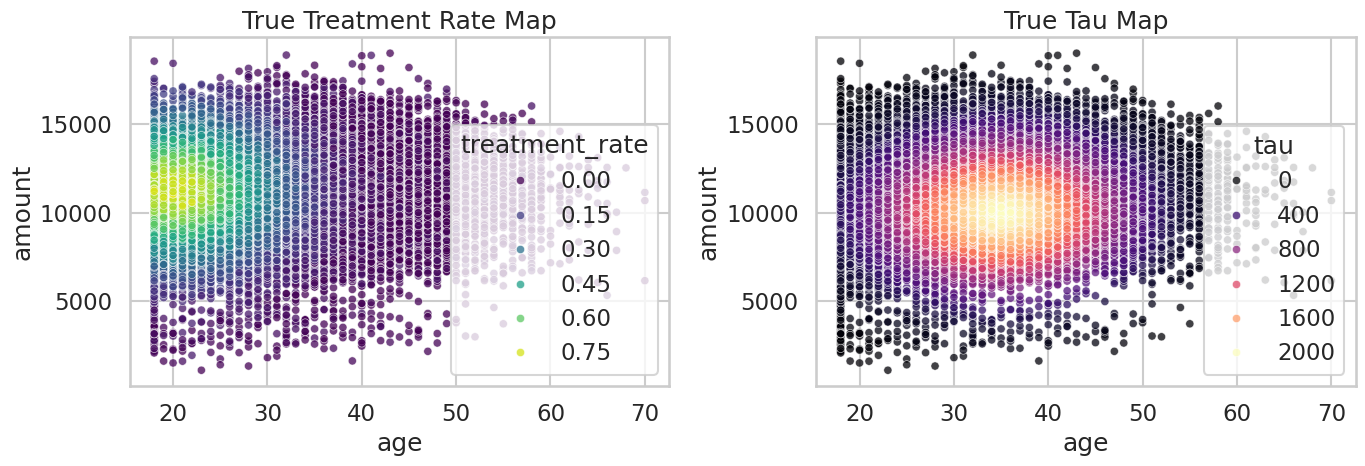

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="amount",
    hue="treatment_rate",
    palette="viridis",
    alpha=0.75,
    s=35,
    ax=axes[0],
)
axes[0].set_title("True Treatment Rate Map")
axes[0].set_xlabel("age")
axes[0].set_ylabel("amount")

sns.scatterplot(
    data=df,
    x="age",
    y="amount",
    hue="tau",
    palette="magma",
    alpha=0.75,
    s=35,
    ax=axes[1],
)
axes[1].set_title("True Tau Map")
axes[1].set_xlabel("age")
axes[1].set_ylabel("amount")

plt.tight_layout()
plt.show()

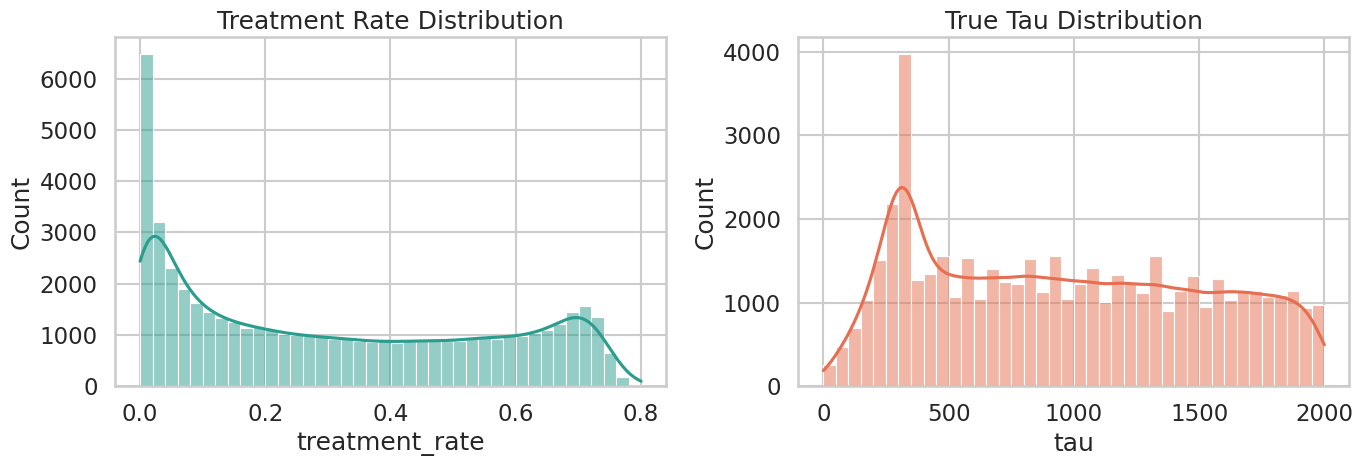

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["treatment_rate"], bins=40, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Treatment Rate Distribution")
axes[0].set_xlabel("treatment_rate")

sns.histplot(df["tau"], bins=40, kde=True, ax=axes[1], color="#e76f51")
axes[1].set_title("True Tau Distribution")
axes[1].set_xlabel("tau")

plt.tight_layout()
plt.show()

## 単純な平均差比較

ここでは最も単純なベースラインとして、

$$
\hat{\tau}_{\mathrm{naive}} = \mathbb{E}[Y \mid T=1] - \mathbb{E}[Y \mid T=0]
$$

を計算し、真の平均効果 `tau.mean()` と比較します。評価指標は ATE の絶対誤差とします。

In [60]:
treated_mean = df.loc[df["treatment"] == 1, "outcome"].mean()
control_mean = df.loc[df["treatment"] == 0, "outcome"].mean()
tau_hat_naive = treated_mean - control_mean

true_ate = df["tau"].mean()
ate_error_naive = abs(true_ate - tau_hat_naive)

print(f"true ATE              : {true_ate:,.2f}")
print(f"treated mean outcome  : {treated_mean:,.2f}")
print(f"control mean outcome  : {control_mean:,.2f}")
print(f"naive ATE estimate    : {tau_hat_naive:,.2f}")
print(f"naive absolute error  : {ate_error_naive:,.2f}")

true ATE              : 957.74
treated mean outcome  : 11,978.60
control mean outcome  : 11,316.39
naive ATE estimate    : 662.21
naive absolute error  : 295.52


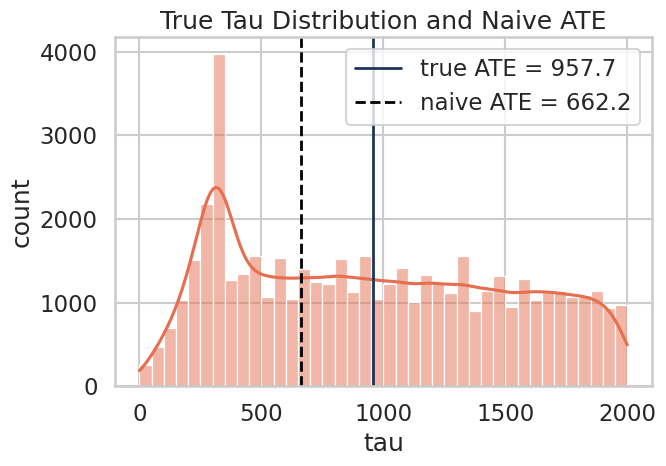

In [61]:
plt.figure(figsize=(7, 5))

sns.histplot(df["tau"], bins=40, kde=True, color="#e76f51")
plt.axvline(true_ate, color="#1d3557", linestyle="-", linewidth=2, label=f"true ATE = {true_ate:.1f}")
plt.axvline(tau_hat_naive, color="black", linestyle="--", linewidth=2, label=f"naive ATE = {tau_hat_naive:.1f}")
plt.title("True Tau Distribution and Naive ATE")
plt.xlabel("tau")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

## 傾向スコアの予測

ここでは `treatment` を目的変数として、各サンプルの傾向スコア

$$
e(x) = P(T=1 \mid X=x)
$$

を予測します。

リークを避けるため、説明変数には介入後の情報や真の生成変数を使いません。具体的には、`outcome`, `tau`, `y0`, `y1`, `treatment_rate` を除外し、`gender` は one-hot エンコーディングします。

In [62]:
feature_cols = ["gender", "age", "recency", "frequency", "amount"]
target_col = "treatment"

X = df[feature_cols].copy()
y = df[target_col].copy()

categorical_features = ["gender"]
numeric_features = ["age", "recency", "frequency", "amount"]

display(X.head())
print("treatment mean:", y.mean())

,gender,age,recency,frequency,amount
0,m,23,7,5,11580
1,f,28,22,6,11378
2,f,21,14,3,10087
3,f,32,10,5,12558
4,m,35,3,4,9199


treatment mean: 0.30902


In [63]:
preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
        ("num", "passthrough", numeric_features),
    ]
)

propensity_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
            ),
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_propensity_score = np.zeros(len(df))

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    propensity_model.fit(X_train, y_train)
    oof_propensity_score[valid_idx] = propensity_model.predict_proba(X_valid)[:, 1]

df_ps = df.copy()
df_ps["propensity_score_est"] = oof_propensity_score

auc_oof = roc_auc_score(y, df_ps["propensity_score_est"])
print(f"OOF ROC-AUC: {auc_oof:.4f}")
display(df_ps[["treatment", "propensity_score_est"] + feature_cols].head())

OOF ROC-AUC: 0.8317


,treatment,propensity_score_est,gender,age,recency,frequency,amount
0,1,0.694537,m,23,7,5,11580
1,1,0.479535,f,28,22,6,11378
2,1,0.671484,f,21,14,3,10087
3,0,0.213643,f,32,10,5,12558
4,1,0.117340,m,35,3,4,9199


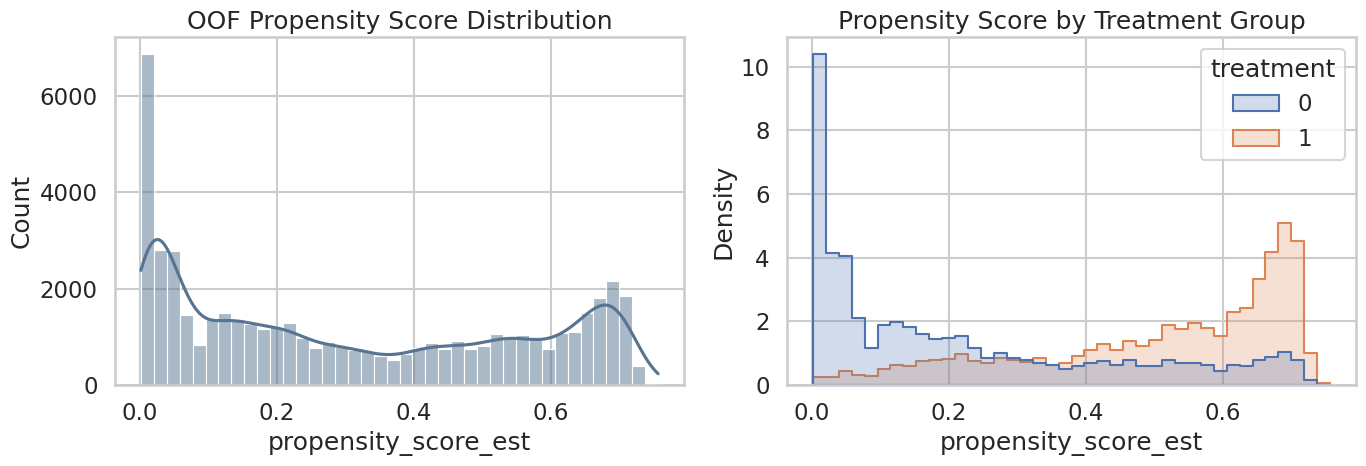

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_ps["propensity_score_est"], bins=40, kde=True, ax=axes[0], color="#577590")
axes[0].set_title("OOF Propensity Score Distribution")
axes[0].set_xlabel("propensity_score_est")

sns.histplot(
    data=df_ps,
    x="propensity_score_est",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[1],
)
axes[1].set_title("Propensity Score by Treatment Group")
axes[1].set_xlabel("propensity_score_est")

plt.tight_layout()
plt.show()

## 逆重みづけ法による ATE の推定

推定した傾向スコア `e(x)` を使って、各サンプルの IPW 擬似アウトカム

$$
\hat{\tau}_{\mathrm{IPW}, i} = \frac{T_i Y_i}{\hat{e}(X_i)} - \frac{(1-T_i)Y_i}{1-\hat{e}(X_i)}
$$

を計算し、その平均で ATE を推定します。

極端な重みを避けるため、傾向スコアは小さくクリップしてから使います。

In [65]:
eps = 1e-3
df_ipw = df_ps.copy()
df_ipw["propensity_score_clipped"] = df_ipw["propensity_score_est"].clip(eps, 1 - eps)

df_ipw["tau_hat_ipw_component"] = (
    df_ipw["treatment"] * df_ipw["outcome"] / df_ipw["propensity_score_clipped"]
    - (1 - df_ipw["treatment"]) * df_ipw["outcome"] / (1 - df_ipw["propensity_score_clipped"])
)

ate_ipw = df_ipw["tau_hat_ipw_component"].mean()
ate_error_ipw = abs(true_ate - ate_ipw)

print(f"true ATE              : {true_ate:,.2f}")
print(f"IPW ATE estimate      : {ate_ipw:,.2f}")
print(f"IPW absolute error    : {ate_error_ipw:,.2f}")
display(df_ipw[["treatment", "outcome", "tau", "propensity_score_est", "tau_hat_ipw_component"]].head())

true ATE              : 957.74
IPW ATE estimate      : 1,031.58
IPW absolute error    : 73.84


,treatment,outcome,tau,propensity_score_est,tau_hat_ipw_component
0,1,12196,712,0.694537,17559.893994
1,1,12717,1324,0.479535,26519.444909
2,1,10820,596,0.671484,16113.570698
3,0,13480,1304,0.213643,-17142.341841
4,1,10626,1934,0.117340,90557.338616


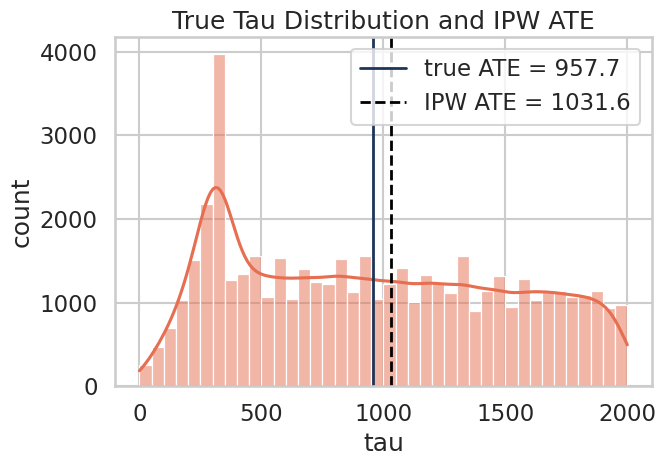

In [66]:
plt.figure(figsize=(7, 5))

sns.histplot(df["tau"], bins=40, kde=True, color="#e76f51")
plt.axvline(true_ate, color="#1d3557", linestyle="-", linewidth=2, label=f"true ATE = {true_ate:.1f}")
plt.axvline(ate_ipw, color="black", linestyle="--", linewidth=2, label=f"IPW ATE = {ate_ipw:.1f}")
plt.title("True Tau Distribution and IPW ATE")
plt.xlabel("tau")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

## 傾向スコアマッチングによる ATE の推定

推定した傾向スコアを使って、各ユニットに対して反対群の最近傍サンプルを 1 件マッチさせます。

treated には最近傍 control の `outcome` を、control には最近傍 treated の `outcome` を対応づけ、擬似的な個票効果を作って平均することで ATE を推定します。

In [70]:
def nearest_opposite_match_outcome(source_df, candidate_df, score_col="propensity_score_est", outcome_col="outcome"):
    source_sorted = source_df[[score_col]].reset_index().rename(columns={"index": "source_index"}).sort_values(score_col)
    candidate_sorted = candidate_df[[score_col, outcome_col]].reset_index().rename(columns={"index": "match_index", outcome_col: "matched_outcome"}).sort_values(score_col)
    candidate_sorted["match_score"] = candidate_sorted[score_col]

    backward = pd.merge_asof(source_sorted, candidate_sorted, on=score_col, direction="backward")
    forward = pd.merge_asof(source_sorted, candidate_sorted, on=score_col, direction="forward")

    backward_gap = (source_sorted[score_col] - backward["match_score"]).abs()
    forward_gap = (forward["match_score"] - source_sorted[score_col]).abs()

    use_forward = backward_gap.isna() | ((~forward_gap.isna()) & (forward_gap < backward_gap))
    matched_outcome = np.where(use_forward, forward["matched_outcome"], backward["matched_outcome"])

    return pd.Series(matched_outcome, index=source_sorted["source_index"]).sort_index()

df_psm = df_ps.copy()
treated_units = df_psm[df_psm["treatment"] == 1]
control_units = df_psm[df_psm["treatment"] == 0]

treated_matched_outcome = nearest_opposite_match_outcome(treated_units, control_units)
control_matched_outcome = nearest_opposite_match_outcome(control_units, treated_units)

df_psm["matched_outcome_psm"] = np.nan
df_psm.loc[treated_units.index, "matched_outcome_psm"] = treated_matched_outcome
df_psm.loc[control_units.index, "matched_outcome_psm"] = control_matched_outcome

df_psm["tau_hat_psm_component"] = np.where(
    df_psm["treatment"] == 1,
    df_psm["outcome"] - df_psm["matched_outcome_psm"],
    df_psm["matched_outcome_psm"] - df_psm["outcome"],
)

psm_ate = df_psm["tau_hat_psm_component"].mean()
ate_error_psm = abs(true_ate - psm_ate)

print(f"true ATE              : {true_ate:,.2f}")
print(f"PSM ATE estimate      : {psm_ate:,.2f}")
print(f"PSM absolute error    : {ate_error_psm:,.2f}")
display(df_psm[["treatment", "outcome", "tau", "propensity_score_est", "matched_outcome_psm", "tau_hat_psm_component"]].head())

true ATE              : 957.74
PSM ATE estimate      : 992.81
PSM absolute error    : 35.07


,treatment,outcome,tau,propensity_score_est,matched_outcome_psm,tau_hat_psm_component
0,1,12196,712,0.694537,10267.0,1929.0
1,1,12717,1324,0.479535,14327.0,-1610.0
2,1,10820,596,0.671484,12514.0,-1694.0
3,0,13480,1304,0.213643,11971.0,-1509.0
4,1,10626,1934,0.117340,9107.0,1519.0


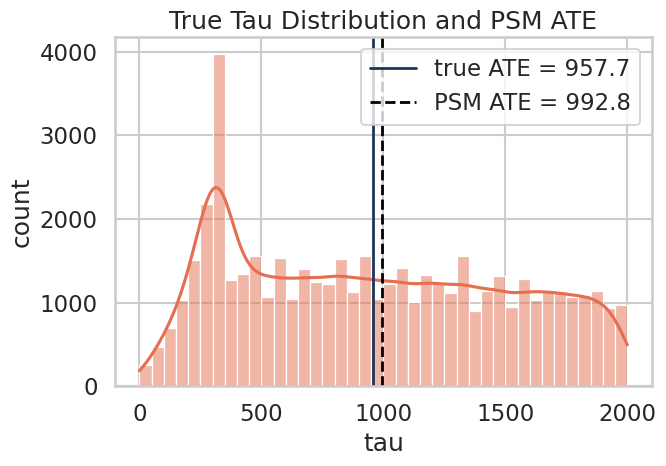

In [71]:
plt.figure(figsize=(7, 5))

sns.histplot(df["tau"], bins=40, kde=True, color="#e76f51")
plt.axvline(true_ate, color="#1d3557", linestyle="-", linewidth=2, label=f"true ATE = {true_ate:.1f}")
plt.axvline(psm_ate, color="black", linestyle="--", linewidth=2, label=f"PSM ATE = {psm_ate:.1f}")
plt.title("True Tau Distribution and PSM ATE")
plt.xlabel("tau")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

,method,ate_estimate,absolute_error
0,naive_mean_diff,662.214638,295.523242
1,ipw_xgb,1031.577877,73.839997
2,psm_xgb,992.812520,35.074640


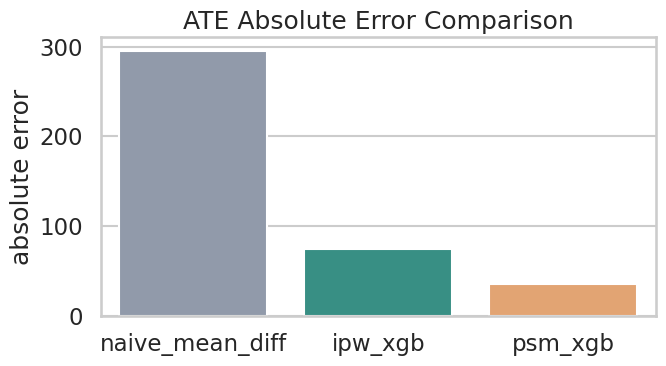

In [72]:
comparison_df = pd.DataFrame(
    {
        "method": ["naive_mean_diff", "ipw_xgb", "psm_xgb"],
        "ate_estimate": [tau_hat_naive, ate_ipw, psm_ate],
        "absolute_error": [ate_error_naive, ate_error_ipw, ate_error_psm],
    }
)

display(comparison_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x="method", y="absolute_error", hue="method", palette=["#8d99ae", "#2a9d8f", "#f4a261"], legend=False)
plt.title("ATE Absolute Error Comparison")
plt.ylabel("absolute error")
plt.xlabel("")
plt.tight_layout()
plt.show()

## データ数を変える実験

介入率を全体の 3 割に保ちながら、データ数 `100, 1000, 5000, 10000, 50000` で同じ検証を回します。

各データ数について、

- 単純平均差による ATE 推定
- XGBoost を使った傾向スコア + IPW による ATE 推定
- XGBoost を使った傾向スコア + PSM による ATE 推定

を計算し、真の ATE との差の絶対値を比較します。

In [73]:
sample_sizes = [100, 1000, 5000, 10000, 50000]
treated_ratio = 0.3
eps = 1e-3

def evaluate_ate_error_by_sample_size(df_input, n, treated_ratio=0.3, random_state=42):
    treated_n = int(round(n * treated_ratio))
    control_n = n - treated_n

    treated_pool = df_input[df_input["treatment"] == 1]
    control_pool = df_input[df_input["treatment"] == 0]

    treated_sample = treated_pool.sample(
        n=treated_n,
        replace=treated_n > len(treated_pool),
        random_state=random_state,
    )
    control_sample = control_pool.sample(
        n=control_n,
        replace=control_n > len(control_pool),
        random_state=random_state + 1,
    )

    sample_df = pd.concat([treated_sample, control_sample], axis=0)
    sample_df = sample_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    true_ate_sample = sample_df["tau"].mean()

    treated_mean_sample = sample_df.loc[sample_df["treatment"] == 1, "outcome"].mean()
    control_mean_sample = sample_df.loc[sample_df["treatment"] == 0, "outcome"].mean()
    naive_ate_sample = treated_mean_sample - control_mean_sample
    naive_error_sample = abs(true_ate_sample - naive_ate_sample)

    X_sample = sample_df[feature_cols].copy()
    y_sample = sample_df[target_col].copy()

    preprocess_sample = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features,
            ),
            ("num", "passthrough", numeric_features),
        ]
    )

    propensity_model_sample = Pipeline(
        steps=[
            ("preprocess", preprocess_sample),
            (
                "model",
                XGBClassifier(
                    n_estimators=200,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=random_state,
                ),
            ),
        ]
    )

    cv_sample = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    oof_propensity_sample = np.zeros(len(sample_df))

    for train_idx, valid_idx in cv_sample.split(X_sample, y_sample):
        X_train = X_sample.iloc[train_idx]
        y_train = y_sample.iloc[train_idx]
        X_valid = X_sample.iloc[valid_idx]

        propensity_model_sample.fit(X_train, y_train)
        oof_propensity_sample[valid_idx] = propensity_model_sample.predict_proba(X_valid)[:, 1]

    propensity_clipped_sample = np.clip(oof_propensity_sample, eps, 1 - eps)
    ipw_component_sample = (
        sample_df["treatment"] * sample_df["outcome"] / propensity_clipped_sample
        - (1 - sample_df["treatment"]) * sample_df["outcome"] / (1 - propensity_clipped_sample)
    )
    ipw_ate_sample = ipw_component_sample.mean()
    ipw_error_sample = abs(true_ate_sample - ipw_ate_sample)

    sample_df_ps = sample_df.copy()
    sample_df_ps["propensity_score_est"] = oof_propensity_sample
    treated_units_sample = sample_df_ps[sample_df_ps["treatment"] == 1]
    control_units_sample = sample_df_ps[sample_df_ps["treatment"] == 0]

    treated_matched_outcome_sample = nearest_opposite_match_outcome(treated_units_sample, control_units_sample)
    control_matched_outcome_sample = nearest_opposite_match_outcome(control_units_sample, treated_units_sample)

    sample_df_ps["matched_outcome_psm"] = np.nan
    sample_df_ps.loc[treated_units_sample.index, "matched_outcome_psm"] = treated_matched_outcome_sample
    sample_df_ps.loc[control_units_sample.index, "matched_outcome_psm"] = control_matched_outcome_sample

    sample_df_ps["tau_hat_psm_component"] = np.where(
        sample_df_ps["treatment"] == 1,
        sample_df_ps["outcome"] - sample_df_ps["matched_outcome_psm"],
        sample_df_ps["matched_outcome_psm"] - sample_df_ps["outcome"],
    )
    psm_ate_sample = sample_df_ps["tau_hat_psm_component"].mean()
    psm_error_sample = abs(true_ate_sample - psm_ate_sample)

    return pd.DataFrame(
        {
            "sample_size": [n, n, n],
            "method": ["naive_mean_diff", "ipw_xgb", "psm_xgb"],
            "true_ate": [true_ate_sample, true_ate_sample, true_ate_sample],
            "ate_estimate": [naive_ate_sample, ipw_ate_sample, psm_ate_sample],
            "mae": [naive_error_sample, ipw_error_sample, psm_error_sample],
        }
    )

sample_size_results = pd.concat(
    [
        evaluate_ate_error_by_sample_size(df, n, treated_ratio=treated_ratio, random_state=42 + i)
        for i, n in enumerate(sample_sizes)
    ],
    ignore_index=True,
)

display(sample_size_results)

,sample_size,method,true_ate,ate_estimate,mae
0,100,naive_mean_diff,969.77000,462.000000,507.770000
1,100,ipw_xgb,969.77000,32812.952001,31843.182001
2,100,psm_xgb,969.77000,730.570000,239.200000
3,1000,naive_mean_diff,983.78400,372.485714,611.298286
4,1000,ipw_xgb,983.78400,2990.544846,2006.760846
5,1000,psm_xgb,983.78400,1390.065000,406.281000
6,5000,naive_mean_diff,958.21460,658.457333,299.757267
7,5000,ipw_xgb,958.21460,1817.829264,859.614664
8,5000,psm_xgb,958.21460,989.820200,31.605600
9,10000,naive_mean_diff,955.94750,583.726190,372.221310


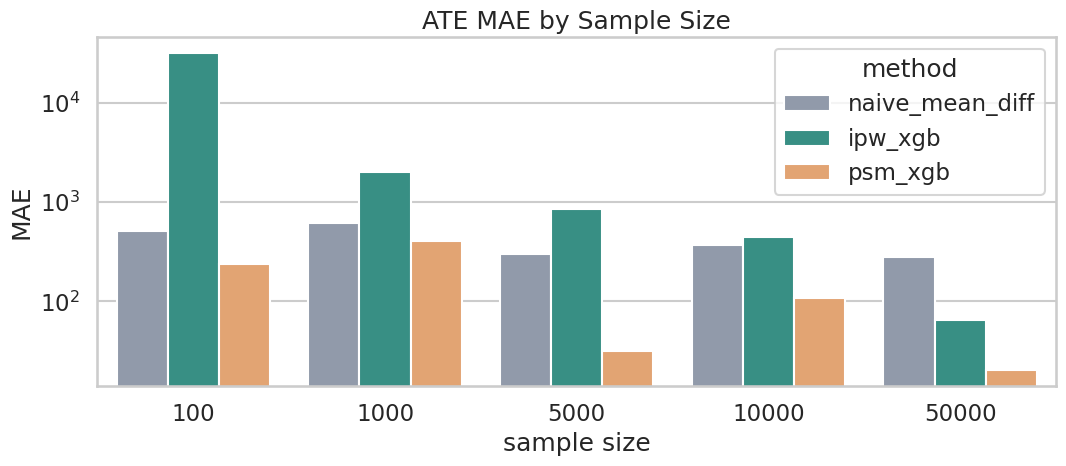

In [74]:
plot_df = sample_size_results.copy()
plot_df["sample_size"] = plot_df["sample_size"].astype(str)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    x="sample_size",
    y="mae",
    hue="method",
    palette=["#8d99ae", "#2a9d8f", "#f4a261"],
)
plt.yscale("log")
plt.title("ATE MAE by Sample Size")
plt.xlabel("sample size")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

## 観察

- 真の `tau` は個人ごとにばらついているため、ここでは個票効果ではなく平均効果 `ATE` を評価対象にします。
- 単純平均差、IPW、PSM をすべて ATE 推定量として扱い、真の平均 `tau.mean()` との差の絶対値で比較します。
- 傾向スコアは `out-of-fold` で作っているため、各行の予測確率はその行自身を学習に使っていません。
- IPW の個票成分 `tau_hat_ipw_component` と PSM の個票成分 `tau_hat_psm_component` はばらつきますが、それぞれの平均を ATE 推定として解釈します。
- データ数実験では、介入率を 3 割に固定したままサンプルサイズを変え、各手法の ATE 推定誤差がどう縮むかを確認します。